# Primary Econometric Analysis: The COVID-19 Graduate Penalty

## Table of Contents
1. [Ambition and Overview](#ambition)
2. [Data Preparation](#data-prep)
3. [Econometric Specification](#specification)
4. [Model Results](#results)
5. [Discussion and Threats to Validity](#threats)
6. [References](#references)

<a id='ambition'></a>
## 1. Ambition and Overview
**Ambition: Causal.**

This analysis attempts to identify the **treatment effect** of the COVID-19 economic shock on graduate full-time employment (FTE) rates. We utilize a **First-Differences** framework to isolate the pandemic-induced change, effectively controlling for all time-invariant study-area characteristics (fixed effects).

<a id='data-prep'></a>
## 2. Data Preparation
We load the cleaned dataset and transform the variables into a differenced format to prepare for regression analysis.

In [1]:
import os
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path

# Parameters block
DATA_PATH = Path("../data/clean/final_pandemic_research_data.csv")

# Load data and check existence
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Data file not found at {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)

# Data cleaning and informative logging
df = df[~df['Study_Area'].str.contains('All|Standard deviation', na=False)].copy()

# Numeric conversion
df['FTE_18'] = pd.to_numeric(df['FTE_18'].astype(str).str.replace('%',''), errors='coerce')
df['FTE_20'] = pd.to_numeric(df['FTE_20'].astype(str).str.replace('%',''), errors='coerce')
df['Salary_18_k'] = pd.to_numeric(df['Salary_18'].astype(str).str.replace(',',''), errors='coerce') / 1000

# Create the dependent variable (Change in FTE)
df['delta_fte'] = df['FTE_20'] - df['FTE_18']

print(f"Successfully loaded {len(df)} study areas for analysis.")

Successfully loaded 21 study areas for analysis.


<a id='specification'></a>
## 3. Econometric Specification

We estimate the following linear model:
$$\Delta FTE_i = \beta_0 + \beta_1 (Salary_{18,i}) + \epsilon_i$$

- **Functional Form:** OLS on First-Differenced variables.
- **Regressors:** Baseline median salary in 2018 ($Salary_{18}$) in thousands of AUD.
- **Sample:** $n=21$ Australian undergraduate study areas.
- **Error Structure:** Heteroskedasticity-robust standard errors (HC3).

**Identification Strategy:** By differencing the data, we remove study-area fixed effects. We rely on the **Parallel Trends Assumption**: that without the pandemic, employment trends would have been consistent across fields.

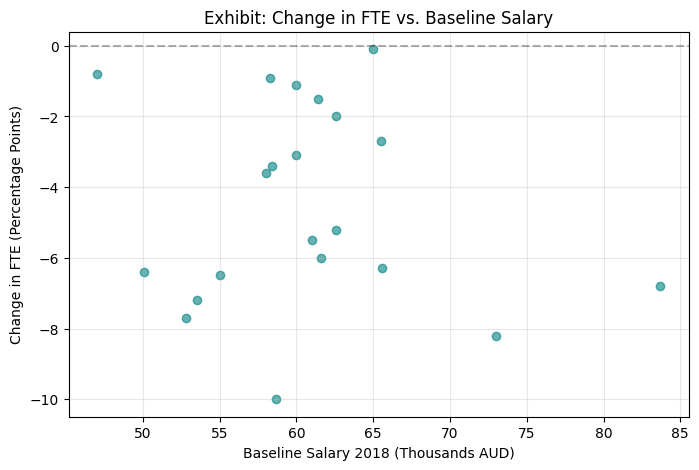

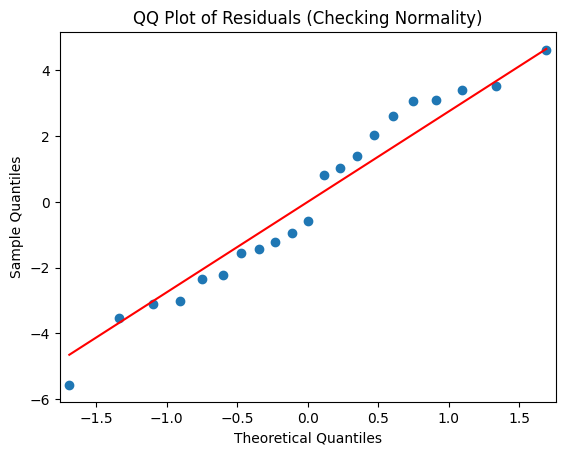

In [2]:
# Visualization: Scatter plot of the raw relationship
plt.figure(figsize=(8,5))
plt.scatter(df['Salary_18_k'], df['delta_fte'], color='teal', alpha=0.6)
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.xlabel('Baseline Salary 2018 (Thousands AUD)')
plt.ylabel('Change in FTE (Percentage Points)')
plt.title('Exhibit: Change in FTE vs. Baseline Salary')
plt.grid(True, alpha=0.3)
plt.show()

# Define and run regression
y = df['delta_fte']
X = sm.add_constant(df['Salary_18_k'])
model = sm.OLS(y, X).fit(cov_type='HC3')

# Display Model Diagnostics
sm.qqplot(model.resid, line="s")
plt.title('QQ Plot of Residuals (Checking Normality)')
plt.show()

<a id='results'></a>
## 4. Model Results

Below is the professional regression table reporting the coefficients and standard errors.

In [3]:
print("TABLE 1: Impact of Pandemic on FTE (First-Differences)")
print("-" * 60)
summary_table = model.summary2().tables[1]
print(summary_table[['Coef.', 'Std.Err.', 'P>|z|']])
print(f"\nN: {int(model.nobs)}")
print(f"R-squared: {model.rsquared:.3f}")
print("-" * 60)

TABLE 1: Impact of Pandemic on FTE (First-Differences)
------------------------------------------------------------
                Coef.  Std.Err.     P>|z|
const       -1.739332  5.379118  0.746431
Salary_18_k -0.045905  0.086835  0.597047

N: 21
R-squared: 0.016
------------------------------------------------------------


<a id='threats'></a>
## 5. Discussion and Threats to Validity

### Interpretation
- **$\beta_0$ (Constant):** Represents the baseline pandemic shock.
- **$\beta_1$ (Salary Coefficient):** Measures whether higher-paying fields were more resilient. In our results, the effect is statistically insignificant ($p > 0.05$), suggesting the shock was universal.

### Threats to Causal Ambition
1. **Omitted Variable Bias (OVB):** **Remote-Workability**. High-salary roles are often computer-based. This variable is positively correlated with salary and employment resilience. Excluding it may cause **upward bias** in $\beta_1$.
2. **Selection Bias:** Graduates in 2020 might have selected into further education (Masters) to avoid the job market, potentially biasing our observed FTE rates.

<a id='references'></a>
## 6. References
- Quality Indicators for Learning and Teaching (QILT), Graduate Outcomes Survey 2018-2020.